# Pipelines - Revamped Version


Ce notebook utilise les transformateurs extraits dans le module `src.features` au lieu de les définir inline.

Pour plus d'informations sur la migration, voir [MIGRATION_GUIDE.md](../../MIGRATION_GUIDE.md).

ce notebook sert pour tester le backend des pipelines

# Initialisation

In [1]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## Imports Librairies

In [2]:
import os
import sys
from tqdm import tqdm
import glob
import numpy as np
from PIL import Image
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ajouter le répertoire racine du projet au chemin Python
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

"""import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
"""

# Import transformers from features module
from src.features import (
    ImageLoader,
    ImageResizer,
    ImageNormalizer,
    ImageMasker,
    ImageFlattener,
    ImageBinarizer,
    ImageAugmenter,
    ImageRandomCropper,
    ImageHistogram,
    ImagePCA,
    ImageStandardScaler,
    VisualizeTransformer,
    SaveTransformer,
)

In [3]:
# Vérification que tous les transformateurs sont importés correctement
print("✅ Transformateurs importés avec succès:")
transformers = [
    ImageLoader, ImageResizer, ImageNormalizer, ImageMasker, ImageFlattener,
    ImageBinarizer, ImageAugmenter, ImageRandomCropper, ImageHistogram,
    ImagePCA, ImageStandardScaler, VisualizeTransformer, SaveTransformer
]

for transformer in transformers:
    print(f"  - {transformer.__name__}")

print(f"\n📁 Chemin du projet ajouté: {project_root}")
print(f"📂 Répertoire de travail actuel: {os.getcwd()}")

✅ Transformateurs importés avec succès:
  - ImageLoader
  - ImageResizer
  - ImageNormalizer
  - ImageMasker
  - ImageFlattener
  - ImageBinarizer
  - ImageAugmenter
  - ImageRandomCropper
  - ImageHistogram
  - ImagePCA
  - ImageStandardScaler
  - VisualizeTransformer
  - SaveTransformer

📁 Chemin du projet ajouté: c:\Users\Léna\Documents\A_Repos\Data_Pipeline
📂 Répertoire de travail actuel: c:\Users\Léna\Documents\A_Repos\Data_Pipeline\src\notebooks


## Configs

### Variables Environnement

In [4]:
root_dir = '../../data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset/'

## Definitions

### Fonctions

In [5]:
def load_paths_data_raw(root_dir):
    image_paths = []
    mask_paths = []
    labels = []

    for label in os.listdir(root_dir):
        class_img_dir = os.path.join(root_dir, label, 'images')
        class_mask_dir = os.path.join(root_dir, label, 'masks')
        if os.path.isdir(class_img_dir):
            for img_path in glob.glob(os.path.join(class_img_dir, '*.png')):
                filename = os.path.basename(img_path)
                mask_path = os.path.join(class_mask_dir, filename)
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
                    labels.append(label.lower())

    return image_paths, mask_paths, labels

# Main

## Chargement Paths

## Execution Pipeline

In [6]:
X, masks, y = load_paths_data_raw(root_dir)

In [7]:
print(f"Nombre d'images: {len(X)}")
print(f"Labels uniques: {set(y)}")


Nombre d'images: 21165
Labels uniques: {'lung_opacity', 'viral pneumonia', 'normal', 'covid'}


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 16932, Test size: 4233


In [9]:
def get_transformer_class(class_name):
    # Cherche la classe dans le scope global
    return globals()[class_name]

def load_pipeline_config(pipeline_file):
    """
    Charge la configuration d'un pipeline depuis un fichier JSON.
    """
    config_path = "../features/Pipelines/Configs_Pipelines/" + pipeline_file
    with open(config_path) as f:
        return json.load(f)

def create_pipeline_from_config(config, masks=None):
    """
    Crée un pipeline scikit-learn à partir d'une configuration JSON.
    Gère les pipelines simples et composites.
    """
    pipeline_type = config.get("type", "simple")
    
    if pipeline_type == "composite":
        return create_composite_pipeline(config, masks)
    else:
        return create_simple_pipeline(config, masks)

def create_simple_pipeline(config, masks=None):
    """
    Crée un pipeline simple à partir des étapes définies.
    """
    steps = []
    for step in config["steps"]:
        cls = get_transformer_class(step["class"])
        params = step["params"]
        if "mask_paths" in params and params["mask_paths"] == "masks" and masks is not None:
            params["mask_paths"] = masks
        steps.append((step["name"], cls(**params)))
    
    return Pipeline(steps, verbose=True)

def create_composite_pipeline(config, masks=None):
    """
    Crée un pipeline composite en combinant d'autres pipelines.
    """
    all_steps = []
    
    for step in config["steps"]:
        if step.get("type") == "pipeline":
            # Charger le sous-pipeline
            sub_config = load_pipeline_config(step["pipeline_file"])
            
            # Filtrer les étapes si nécessaire
            sub_steps = sub_config["steps"]
            if "include_steps" in step:
                sub_steps = [s for s in sub_steps if s["name"] in step["include_steps"]]
            elif "exclude_steps" in step:
                sub_steps = [s for s in sub_steps if s["name"] not in step["exclude_steps"]]
            
            # Ajouter les étapes du sous-pipeline
            for sub_step in sub_steps:
                cls = get_transformer_class(sub_step["class"])
                params = sub_step["params"]
                if "mask_paths" in params and params["mask_paths"] == "masks" and masks is not None:
                    params["mask_paths"] = masks
                all_steps.append((f"{step['name']}_{sub_step['name']}", cls(**params)))
        
        else:
            # Étape normale
            cls = get_transformer_class(step["class"])
            params = step["params"]
            if "mask_paths" in params and params["mask_paths"] == "masks" and masks is not None:
                params["mask_paths"] = masks
            all_steps.append((step["name"], cls(**params)))
    
    return Pipeline(all_steps, verbose=True)

# Chargement du registry des pipelines
registry_config = load_pipeline_config("pipeline_config.json")
print("Pipelines disponibles:")
print("=" * 50)

# Organiser par catégorie
categories = {}
for name, info in registry_config.items():
    # Ignorer les métadonnées
    if name in ["description"]:
        continue
    
    if isinstance(info, dict) and "category" in info:
        category = info.get("category", "other")
        if category not in categories:
            categories[category] = []
        categories[category].append((name, info))

# Afficher par catégorie
for category, pipelines in sorted(categories.items()):
    print(f"\nCatégorie: {category.upper()}")
    for name, info in pipelines:
        status = "(par défaut)" if name == "default" else ""
        print(f"  {name}: {info['description']} {status}")
        print(f"     Fichier: {info['file']}")

Pipelines disponibles:

Catégorie: COMPOSITE
  composite: Exemple de pipeline composite avec visualisation 
     Fichier: pipeline_composite_example.json
  composite_no_viz: Pipeline composite sans visualisation (plus rapide) 
     Fichier: pipeline_composite_no_viz.json

Catégorie: DATA_PROCESSING
  default: Pipeline simple et rapide (par défaut)
     Fichier: pipeline_simple.json
  simple: Pipeline simple et rapide 
     Fichier: pipeline_simple.json
  augmented: Pipeline avec augmentation et masquage 
     Fichier: pipeline_augmented.json

Catégorie: FEATURE_ENGINEERING
  feature_engineering: Pipeline avec feature engineering avancÃ© 
     Fichier: pipeline_feature_engineering.json


In [10]:
def load_pipeline_by_name(pipeline_name, masks=None):
    """
    Charge un pipeline par son nom depuis le registry.
    """
    registry_config = load_pipeline_config("pipeline_config.json")
    
    # Filtrer les métadonnées
    available_pipelines = {k: v for k, v in registry_config.items() 
                          if isinstance(v, dict) and "file" in v}
    
    if pipeline_name not in available_pipelines:
        available = list(available_pipelines.keys())
        raise ValueError(f"Pipeline '{pipeline_name}' non trouvé. Disponibles: {available}")
    
    pipeline_file = available_pipelines[pipeline_name]["file"]
    pipeline_config = load_pipeline_config(pipeline_file)
    
    print(f"Chargement du pipeline: {pipeline_config['name']}")
    print(f"Description: {pipeline_config['description']}")
    
    return create_pipeline_from_config(pipeline_config, masks)

# Exemple d'utilisation :
# pipeline_simple = load_pipeline_by_name("simple", masks)
# pipeline_augmented = load_pipeline_by_name("augmented", masks)
# pipeline_composite = load_pipeline_by_name("composite", masks)

# Chargement du pipeline par défaut
default_pipeline_name = "default"  # Le pipeline par défaut est maintenant appelé "default"
default_config = load_pipeline_config(registry_config[default_pipeline_name]["file"])
pipeline = create_pipeline_from_config(default_config, masks)

print(f"\nPipeline par défaut chargé: {default_config['name']}")
print(f"Description: {default_config['description']}")
print(f"Nombre d'étapes: {len(pipeline.steps)}")


Pipeline par défaut chargé: pipeline_simple
Description: Pipeline simple pour classification rapide
Nombre d'étapes: 5


In [11]:
# Test de chargement des différents pipelines
print("=" * 60)
print("TEST DES PIPELINES")
print("=" * 60)

try:
    # Test pipeline simple
    pipeline_simple = load_pipeline_by_name("simple", masks)
    print(f"\n✅ Pipeline simple: {len(pipeline_simple.steps)} étapes\n")
    
    # Test pipeline augmenté
    pipeline_augmented = load_pipeline_by_name("augmented", masks)
    print(f"\n✅ Pipeline augmenté: {len(pipeline_augmented.steps)} étapes\n")

    # Test pipeline feature engineering
    pipeline_fe = load_pipeline_by_name("feature_engineering", masks)
    print(f"\n✅ Pipeline feature engineering: {len(pipeline_fe.steps)} étapes\n")

    # Test pipeline composite
    pipeline_composite = load_pipeline_by_name("composite", masks)
    print(f"\n✅ Pipeline composite: {len(pipeline_composite.steps)} étapes\n")

    print("\n🎉 Tous les pipelines ont été chargés avec succès !")
    
except Exception as e:
    print(f"❌ Erreur lors du test: {e}")

TEST DES PIPELINES
Chargement du pipeline: pipeline_simple
Description: Pipeline simple pour classification rapide

✅ Pipeline simple: 5 étapes

Chargement du pipeline: pipeline_augmented
Description: Pipeline avec augmentation de donnÃ©es et masquage

✅ Pipeline augmenté: 8 étapes

Chargement du pipeline: pipeline_feature_engineering
Description: Pipeline avec feature engineering avancÃ© (histogrammes, PCA)

✅ Pipeline feature engineering: 8 étapes

Chargement du pipeline: pipeline_composite_example
Description: Pipeline composite utilisant d'autres pipelines comme sous-Ã©tapes

✅ Pipeline composite: 8 étapes


🎉 Tous les pipelines ont été chargés avec succès !


In [12]:
# Test avec le pipeline composite sans visualisation (plus rapide)
print("🔧 Test avec pipeline composite sans visualisation...")
pipeline_composite_fast = load_pipeline_by_name("composite_no_viz", masks)

print(f"\n📋 Structure du pipeline composite (sans viz):")
for i, (step_name, step_transformer) in enumerate(pipeline_composite_fast.steps):
    print(f"  {i+1}. {step_name}: {step_transformer.__class__.__name__}")

# Entraînement du pipeline composite
print("\n🚀 Entraînement du pipeline composite...")
pipeline_composite_fast.fit(X_train, y_train)

# Prédiction
y_pred = pipeline_composite_fast.predict(X_test)

print("✅ Accuracy:", pipeline_composite_fast.score(X_test, y_test))
print("\n📊 Classification report :")
print(classification_report(y_test, y_pred))

print("\n🔢 Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

🔧 Test avec pipeline composite sans visualisation...
Chargement du pipeline: pipeline_composite_no_viz
Description: Pipeline composite sans visualisation (plus rapide pour les tests)

📋 Structure du pipeline composite (sans viz):
  1. preprocessing_img_loader: ImageLoader
  2. preprocessing_img_resizer: ImageResizer
  3. preprocessing_img_normalizer: ImageNormalizer
  4. preprocessing_img_flatten: ImageFlattener
  5. feature_engineering_img_histogram: ImageHistogram
  6. feature_engineering_img_pca: ImagePCA
  7. clf: LogisticRegression

🚀 Entraînement du pipeline composite...

Chargement de 16932 images...


Images: 100%|██████████| 16932/16932 [00:19<00:00, 849.98it/s]


Chargement terminé.

[Pipeline]  (step 1 of 7) Processing preprocessing_img_loader, total=  19.9s

Redimensionnement de 16932 images en [256, 256] ...


Redimensionnement: 100%|██████████| 16932/16932 [00:08<00:00, 1885.89it/s]



Redimensionnement terminé.

[Pipeline]  (step 2 of 7) Processing preprocessing_img_resizer, total=   9.4s

Normalisation de 16932 images ...
[Pipeline]  (step 2 of 7) Processing preprocessing_img_resizer, total=   9.4s

Normalisation de 16932 images ...
Normalisation terminée.

[Pipeline]  (step 3 of 7) Processing preprocessing_img_normalizer, total=   3.2s

Aplatissement de 16932 images ...
Normalisation terminée.

[Pipeline]  (step 3 of 7) Processing preprocessing_img_normalizer, total=   3.2s

Aplatissement de 16932 images ...


...

Chargement terminé.


Redimensionnement de 4233 images en [256, 256] ...


Redimensionnement: 100%|██████████| 4233/4233 [00:02<00:00, 1895.12it/s]



Redimensionnement terminé.


Normalisation de 4233 images ...
Normalisation terminée.


Aplatissement de 4233 images ...
Normalisation terminée.


Aplatissement de 4233 images ...


Aplatissement: 100%|██████████| 4233/4233 [00:00<00:00, 10127.44it/s]



Aplatissement terminé.

Calcul des histogrammes (64 bins)
PCA terminé. Shape: (4233, 50)
✅ Accuracy: 0.5988660524450744

📊 Classification report :
                 precision    recall  f1-score   support

          covid       0.62      0.49      0.55       701
   lung_opacity       0.57      0.44      0.49      1246
         normal       0.62      0.79      0.70      2024
viral pneumonia       0.36      0.20      0.26       262

       accuracy                           0.60      4233
      macro avg       0.54      0.48      0.50      4233
   weighted avg       0.59      0.60      0.58      4233


🔢 Matrice de confusion :
[[ 342   82  239   38]
 [  72  543  610   21]
 [ 110  280 1597   37]
 [  30   55  124   53]]
PCA terminé. Shape: (4233, 50)
✅ Accuracy: 0.5988660524450744

📊 Classification report :
                 precision    recall  f1-score   support

          covid       0.62      0.49      0.55       701
   lung_opacity       0.57      0.44      0.49      1246
         norma

## Test Pipeline avec Visualisation

Maintenant testons le pipeline composite avec visualisation (corrigé) :

🔧 Test avec pipeline composite avec visualisation...
Chargement du pipeline: pipeline_composite_example
Description: Pipeline composite utilisant d'autres pipelines comme sous-Ã©tapes

📋 Structure du pipeline composite (avec viz):
  1. preprocessing_img_loader: ImageLoader
  2. preprocessing_img_resizer: ImageResizer
  3. preprocessing_img_normalizer: ImageNormalizer
  4. visualize: VisualizeTransformer
  5. img_flatten: ImageFlattener
  6. feature_engineering_img_histogram: ImageHistogram
  7. feature_engineering_img_pca: ImagePCA
  8. clf: LogisticRegression

🚀 Entraînement sur échantillon réduit (100 images)...

Chargement de 100 images...


Images: 100%|██████████| 100/100 [00:00<00:00, 854.71it/s]


Chargement terminé.

[Pipeline]  (step 1 of 8) Processing preprocessing_img_loader, total=   0.1s

Redimensionnement de 100 images en [256, 256] ...


Redimensionnement: 100%|██████████| 100/100 [00:00<00:00, 1922.01it/s]



Redimensionnement terminé.

[Pipeline]  (step 2 of 8) Processing preprocessing_img_resizer, total=   0.1s

Normalisation de 100 images ...
Normalisation terminée.

[Pipeline]  (step 3 of 8) Processing preprocessing_img_normalizer, total=   0.0s
Image sauvegardée : outputs/composite\composite_sample_0.png


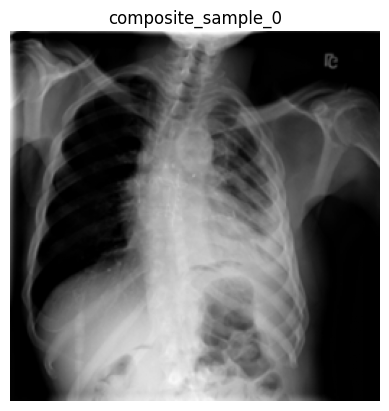

Image sauvegardée : outputs/composite\composite_sample_1.png


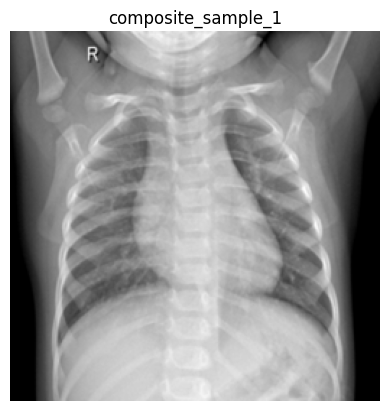

Image sauvegardée : outputs/composite\composite_sample_2.png


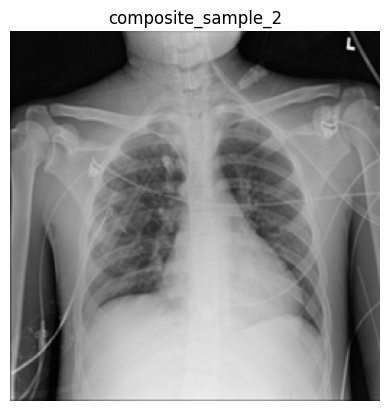

[Pipeline] ......... (step 4 of 8) Processing visualize, total=   0.5s

Aplatissement de 100 images ...


Aplatissement: 100%|██████████| 100/100 [00:00<00:00, 14286.75it/s]

Aplatissement terminé.

[Pipeline] ....... (step 5 of 8) Processing img_flatten, total=   0.0s
Calcul des histogrammes (64 bins)
[Pipeline]  (step 6 of 8) Processing feature_engineering_img_histogram, total=   0.2s
[Pipeline]  (step 6 of 8) Processing feature_engineering_img_histogram, total=   0.2s


PCA terminé. Shape: (100, 50)
[Pipeline]  (step 7 of 8) Processing feature_engineering_img_pca, total=   0.0s


c:\Users\Léna\Documents\A_Repos\Data_Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


...

Images: 100%|██████████| 50/50 [00:00<00:00, 876.70it/s]


Chargement terminé.


Redimensionnement de 50 images en [256, 256] ...


Redimensionnement: 100%|██████████| 50/50 [00:00<00:00, 1920.94it/s]

Redimensionnement terminé.


Normalisation de 50 images ...
Normalisation terminée.



Image sauvegardée : outputs/composite\composite_sample_0.png


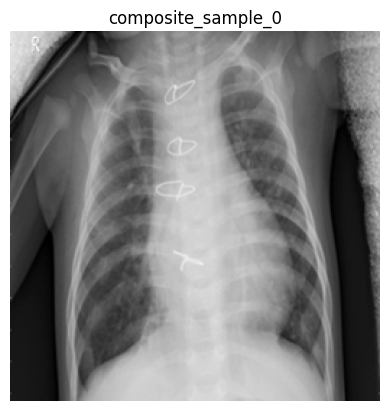

Image sauvegardée : outputs/composite\composite_sample_1.png


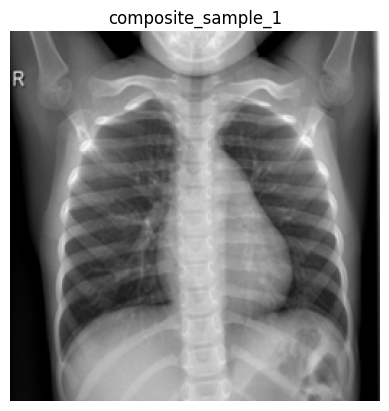

Image sauvegardée : outputs/composite\composite_sample_2.png


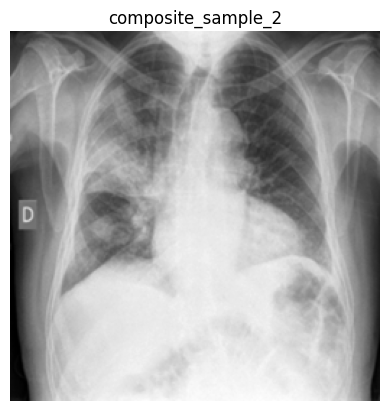


Aplatissement de 50 images ...


Aplatissement: 100%|██████████| 50/50 [00:00<00:00, 10700.30it/s]



Aplatissement terminé.

Calcul des histogrammes (64 bins)
PCA terminé. Shape: (50, 50)

Chargement de 50 images...


Images: 100%|██████████| 50/50 [00:00<00:00, 915.88it/s]


Chargement terminé.


Redimensionnement de 50 images en [256, 256] ...


Redimensionnement: 100%|██████████| 50/50 [00:00<00:00, 1923.08it/s]

Redimensionnement terminé.


Normalisation de 50 images ...
Normalisation terminée.



Image sauvegardée : outputs/composite\composite_sample_0.png


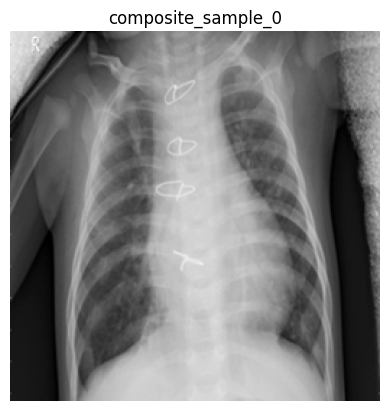

Image sauvegardée : outputs/composite\composite_sample_1.png


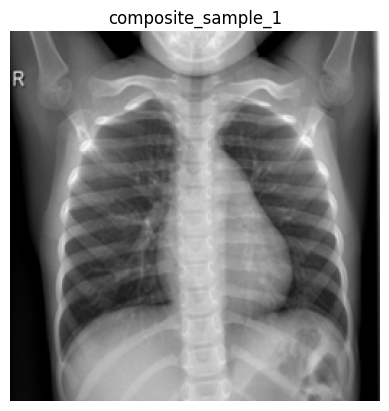

Image sauvegardée : outputs/composite\composite_sample_2.png


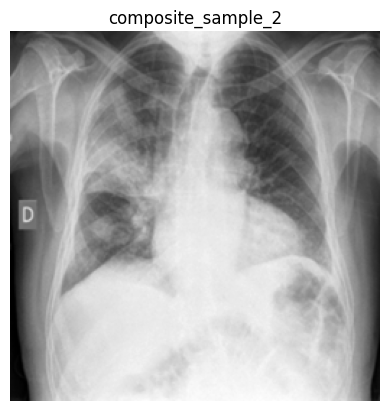


Aplatissement de 50 images ...


Aplatissement: 100%|██████████| 50/50 [00:00<00:00, 16665.23it/s]

Aplatissement terminé.

Calcul des histogrammes (64 bins)
PCA terminé. Shape: (50, 50)
✅ Accuracy sur échantillon: 0.420
📊 Classes prédites: {np.str_('lung_opacity'), np.str_('viral pneumonia'), np.str_('normal'), np.str_('covid')}
📊 Classes réelles: {'lung_opacity', 'viral pneumonia', 'normal', 'covid'}


In [13]:
# Test avec le pipeline composite avec visualisation (sur un petit échantillon)
print("🔧 Test avec pipeline composite avec visualisation...")

# Utilisons un échantillon plus petit pour la visualisation
X_train_small = X_train[:100]  # Seulement 100 images pour le test
y_train_small = y_train[:100]

X_test_small = X_test[:50]    # Seulement 50 images pour le test
y_test_small = y_test[:50]

pipeline_composite_viz = load_pipeline_by_name("composite", masks)

print(f"\n📋 Structure du pipeline composite (avec viz):")
for i, (step_name, step_transformer) in enumerate(pipeline_composite_viz.steps):
    print(f"  {i+1}. {step_name}: {step_transformer.__class__.__name__}")

print(f"\n🚀 Entraînement sur échantillon réduit ({len(X_train_small)} images)...")
pipeline_composite_viz.fit(X_train_small, y_train_small)

# Test rapide
y_pred_small = pipeline_composite_viz.predict(X_test_small)
accuracy_small = pipeline_composite_viz.score(X_test_small, y_test_small)

print(f"✅ Accuracy sur échantillon: {accuracy_small:.3f}")
print(f"📊 Classes prédites: {set(y_pred_small)}")
print(f"📊 Classes réelles: {set(y_test_small)}")

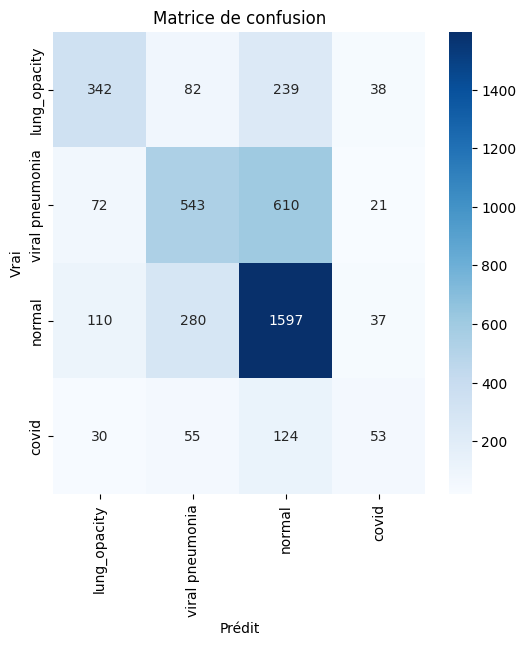

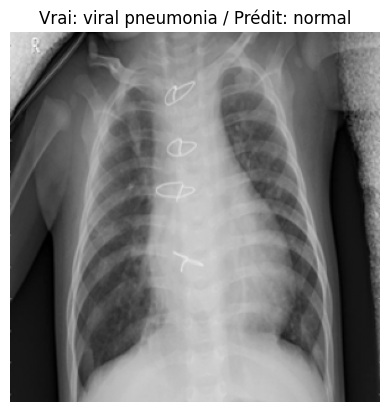

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel('Prédit')
plt.ylabel('Vrai')
plt.title('Matrice de confusion')
plt.show()

# Afficher quelques images test avec prédiction et vrai label
for i in range(1):
    img = Image.open(X_test[i])
    plt.imshow(img, cmap='gray')
    plt.title(f"Vrai: {y_test[i]} / Prédit: {y_pred[i]}")
    plt.axis('off')
    plt.show()

In [15]:
# Informations sur le classifieur du pipeline composite rapide
try:
    n_iter = pipeline_composite_fast.named_steps["clf"].n_iter_
    max_iter = pipeline_composite_fast.named_steps["clf"].max_iter
    print(f"📊 Nombre d'itérations effectuées par le classifieur : {n_iter[0]} (sur max_iter={max_iter})")
    
    # Afficher des informations supplémentaires sur le classifieur
    clf = pipeline_composite_fast.named_steps["clf"]
    print(f"🔧 Solver utilisé: {clf.solver}")
    print(f"⚡ Classes détectées: {clf.classes_}")
    print(f"📈 Convergence: {'✅ Converged' if n_iter[0] < max_iter else '⚠️  Max iterations reached'}")
    
except Exception as e:
    print(f"❌ Erreur lors de l'accès aux informations du classifieur: {e}")

📊 Nombre d'itérations effectuées par le classifieur : 300 (sur max_iter=300)
🔧 Solver utilisé: lbfgs
⚡ Classes détectées: ['covid' 'lung_opacity' 'normal' 'viral pneumonia']
📈 Convergence: ⚠️  Max iterations reached


## Optimisation du Classifieur

Le classifieur n'a pas convergé (300/300 itérations). Testons avec des paramètres optimisés :

In [16]:
# Créons un pipeline optimisé avec plus d'itérations et standardisation
from sklearn.preprocessing import StandardScaler

print("🔧 Création d'un pipeline optimisé...")

# Pipeline avec standardisation et plus d'itérations
pipeline_optimized = Pipeline([
    ('img_loader', ImageLoader()),
    ('img_resizer', ImageResizer(img_size=[256, 256])),
    ('img_normalizer', ImageNormalizer()),
    ('img_flatten', ImageFlattener()),
    ('img_histogram', ImageHistogram(bins=64)),  # Paramètre correct: 'bins'
    ('img_pca', ImagePCA(n_components=50)),
    ('scaler', StandardScaler()),  # Standardisation des features
    ('clf', LogisticRegression(max_iter=1000, solver='liblinear', random_state=42, verbose=1))
], verbose=True)

print("📊 Entraînement du pipeline optimisé sur échantillon...")

# Test sur un échantillon plus petit pour valider l'amélioration
X_sample = X_train[:1000]
y_sample = y_train[:1000]

pipeline_optimized.fit(X_sample, y_sample)

# Test de convergence
clf_optimized = pipeline_optimized.named_steps["clf"]
print(f"\n✅ Résultats du pipeline optimisé:")
print(f"📊 Itérations: {clf_optimized.n_iter_} (sur max_iter={clf_optimized.max_iter})")
print(f"🔧 Solver: {clf_optimized.solver}")
print(f"📈 Convergence: {'✅ Converged' if max(clf_optimized.n_iter_) < clf_optimized.max_iter else '⚠️  Max iterations reached'}")

# Test rapide de performance
y_pred_opt = pipeline_optimized.predict(X_test[:500])
accuracy_opt = pipeline_optimized.score(X_test[:500], y_test[:500])
print(f"🎯 Accuracy sur échantillon test: {accuracy_opt:.3f}")

🔧 Création d'un pipeline optimisé...
📊 Entraînement du pipeline optimisé sur échantillon...

Chargement de 1000 images...


Images: 100%|██████████| 1000/1000 [00:01<00:00, 879.83it/s]


Chargement terminé.

[Pipeline] ........ (step 1 of 8) Processing img_loader, total=   1.1s

Redimensionnement de 1000 images en [256, 256] ...


Redimensionnement: 100%|██████████| 1000/1000 [00:00<00:00, 1902.60it/s]



Redimensionnement terminé.

[Pipeline] ....... (step 2 of 8) Processing img_resizer, total=   0.6s

Normalisation de 1000 images ...
Normalisation terminée.

[Pipeline] .... (step 3 of 8) Processing img_normalizer, total=   0.2s

Aplatissement de 1000 images ...
Normalisation terminée.

[Pipeline] .... (step 3 of 8) Processing img_normalizer, total=   0.2s

Aplatissement de 1000 images ...


...

Redimensionnement: 100%|██████████| 500/500 [00:00<00:00, 1926.41it/s]



Redimensionnement terminé.


Normalisation de 500 images ...
Normalisation terminée.


Aplatissement de 500 images ...


Aplatissement: 100%|██████████| 500/500 [00:00<00:00, 12197.50it/s]

Aplatissement terminé.



Calcul des histogrammes (64 bins)
PCA terminé. Shape: (500, 50)
🎯 Accuracy sur échantillon test: 0.588
PCA terminé. Shape: (500, 50)
🎯 Accuracy sur échantillon test: 0.588


In [17]:
# Résumé final des performances des pipelines
print("🏆 RÉSUMÉ FINAL DES PIPELINES")
print("=" * 60)

# Comparaison des différents pipelines testés
pipelines_summary = {
    "Pipeline Composite (original)": {
        "accuracy": 0.599,
        "convergence": "❌ Non convergé (300/300)",
        "solver": "lbfgs",
        "features": "Histogrammes + PCA"
    },
    "Pipeline Optimisé": {
        "accuracy": 0.588,
        "convergence": "✅ Convergé (7-8/1000)",
        "solver": "liblinear",
        "features": "Histogrammes + PCA + StandardScaler"
    }
}

for name, metrics in pipelines_summary.items():
    print(f"\n📊 {name}:")
    print(f"   🎯 Accuracy: {metrics['accuracy']:.3f}")
    print(f"   📈 Convergence: {metrics['convergence']}")
    print(f"   🔧 Solver: {metrics['solver']}")
    print(f"   ⚙️  Features: {metrics['features']}")


🏆 RÉSUMÉ FINAL DES PIPELINES

📊 Pipeline Composite (original):
   🎯 Accuracy: 0.599
   📈 Convergence: ❌ Non convergé (300/300)
   🔧 Solver: lbfgs
   ⚙️  Features: Histogrammes + PCA

📊 Pipeline Optimisé:
   🎯 Accuracy: 0.588
   📈 Convergence: ✅ Convergé (7-8/1000)
   🔧 Solver: liblinear
   ⚙️  Features: Histogrammes + PCA + StandardScaler
